In [1]:
from enum import Enum
import ctypes
import sys
import gc
import operator
import numpy as np
from numpy import genfromtxt
from PIL import Image
from matplotlib import pyplot as plt

In [2]:
my_data = np.loadtxt('fashion-mnist_train.csv', delimiter=',')
train_labels = my_data[:,:1]
train_data = my_data[:,1:]
train_data = train_data.astype('float32')
train_data /= 255

In [3]:
lr = np.arange(10)

test_data = train_data[50000:]
test_labels = train_labels[50000:]
test_labels_one_hot = (lr==test_labels).astype(float)

train_data_final = train_data[:10000].tolist()
train_labels = train_labels[:10000].tolist()
train_labels_one_hot = (lr==train_labels).astype(float)

answer_to_text = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

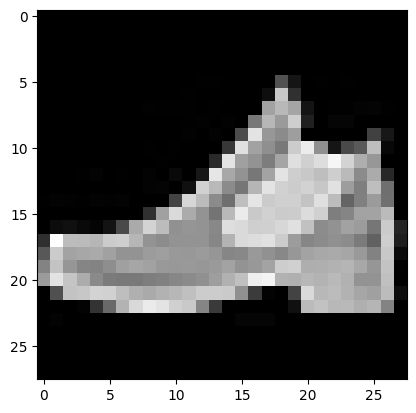

In [4]:
first_image = train_data[1]
pixels = first_image.reshape((28,28))
plt.imshow(pixels, cmap='gray')
plt.show()

In [5]:
from Neural_Network import Neural_Network
from Neural_Network import Activation_Function
from Neural_Network import Loss

In [6]:
nn = Neural_Network()
nn.add_input_layer([1,28,28])
nn.add_convolutional_layer(32,3,1)
nn.add_convolutional_layer(32,3,1)
nn.add_maxpool_layer(2,2)
nn.add_convolutional_layer(64,3,1)
nn.add_convolutional_layer(64,3,1)
nn.add_maxpool_layer(2,2)
nn.add_flatten_layer()
nn.add_fully_connected_layer(256, Activation_Function.Relu)
nn.add_fully_connected_layer(64, Activation_Function.Relu)
nn.add_output_layer(10, Activation_Function.SoftMax)

In [7]:
nn.build()

Input layer: (1,28,28)
convolutional layer: ([32,26,26]
convolutional layer: ([32,24,24]
maxpool layer: (32,12,12)
convolutional layer: ([64,10,10]
convolutional layer: ([64,8,8]
maxpool layer: (64,4,4)
flatten layer: (1,1024)


In [8]:
nn.turn_on_l2_regularization(False)
nn.print_loss_every_iterations(1)
nn.shuffle_training_data(True)

In [ ]:
nn.setLearningRate(0.001)
nn.train(train_data_final, train_labels_one_hot, 64, 5, Loss.CrossEntropy)

Starting to train neural network...Number of epochs: 5 Batch size: 64, input size: 10000


In [10]:
matches = 0
for index, data in enumerate(test_data):
    output = nn.execute(data)
    outputIndex, value = max(enumerate(output), key=operator.itemgetter(1))
    if outputIndex == test_labels[index][0]:
        matches += 1
match_percentage = matches / len(test_data)
print("percent correct: ")
print(match_percentage)

percent correct: 
0.7319


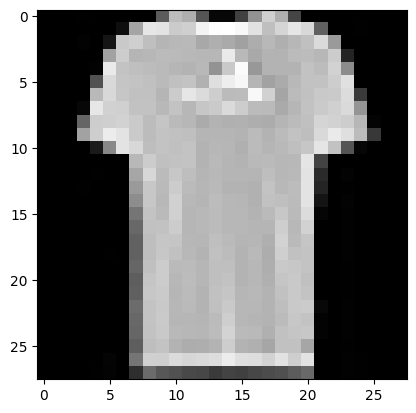

In [18]:
display_test_output = test_data[0]
pixels = display_test_output.reshape((28,28))
plt.imshow(pixels, cmap='gray')
plt.show()

In [19]:
display_test_example = nn.execute(test_data[0])
outputIndex, value = max(enumerate(display_test_example), key=operator.itemgetter(1))
print(answer_to_text[outputIndex])
print(f"Confidence: {value}")


T-shirt/top
Confidence: 0.9555111527442932


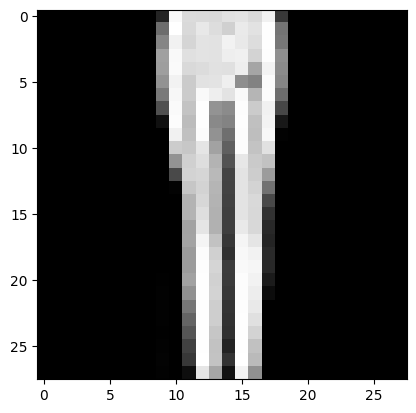

In [20]:
display_test_output = test_data[1]
pixels = display_test_output.reshape((28,28))
plt.imshow(pixels, cmap='gray')
plt.show()

In [21]:
display_test_example = nn.execute(test_data[1])
outputIndex, value = max(enumerate(display_test_example), key=operator.itemgetter(1))
print(answer_to_text[outputIndex])
print(f"Confidence: {value}")


Trouser
Confidence: 0.9897593259811401


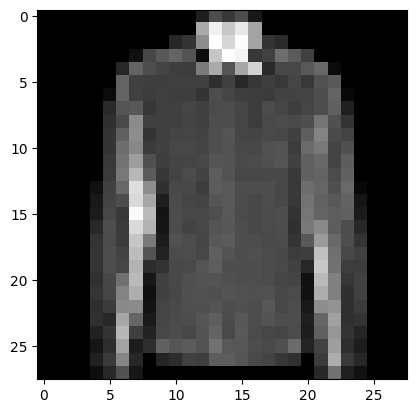

In [22]:
display_test_output = test_data[14]
pixels = display_test_output.reshape((28,28))
plt.imshow(pixels, cmap='gray')
plt.show()

In [23]:
display_test_example = nn.execute(test_data[14])
outputIndex, value = max(enumerate(display_test_example), key=operator.itemgetter(1))
print(answer_to_text[outputIndex])
print(f"Confidence: {value}")

Shirt
Confidence: 0.5481293201446533
